# $\text{CO}_{2}$ System Solver
> Andrew McGallian

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
# Givens
K1 = 10**(-6.5)
K2 = 10**(-10.8)
K_henry = 10.0**(1.5) / 1000  # mol/L/atm
K_water = 10**(-14)

pH_low = 1.0
pH_high = 14.0

alk = 2.0 / 1000  # mol/L
DIC = 2.0 / 1000  # mol/L

sanity_pCO2 = 507  # ppm
sanity_pH = 8.59   # unitless


# Helper functions for the buffer system
def calc_alpha0(h_plus):  # CO2 from h_plus
    return (h_plus**2) / (h_plus**2 + (K1 * h_plus) + (K1 * K2))


def calc_alpha1(h_plus):  # HCO3- from h_plus
    return (K1 * h_plus) / (h_plus**2 + (K1 * h_plus) + (K1 * K2))


def calc_alpha2(h_plus):  # CO3^2- from h_plus
    return (K1 * K2) / (h_plus**2 + (K1 * h_plus) + (K1 * K2))


def solve_for_alk(DIC, alpha1, alpha2, h_plus):
    return DIC * (alpha1 + (2 * alpha2)) + (K_water / h_plus) - h_plus


def system_solver(pH_guess, DIC):
    h_plus = 10**(-pH_guess)
    alpha1 = calc_alpha1(h_plus)
    alpha2 = calc_alpha2(h_plus)
    alk_guess = solve_for_alk(DIC, alpha1, alpha2, h_plus)
    return alk_guess


def solver_loop(pH_low, pH_high, DIC, alk, iterations=20):
    pH_mid = (pH_low + pH_high) / 2

    for _ in range(iterations):
        alk_guess = system_solver(pH_mid, DIC)

        if alk_guess < alk:
            pH_low = pH_mid
        else:
            pH_high = pH_mid

        pH_mid = (pH_low + pH_high) / 2
    
    CO2_conc = DIC * calc_alpha0(10**(-pH_mid))
    CO3_conc = DIC * calc_alpha2(10**(-pH_mid))
    pCO2_conc = CO2_conc / K_henry

    return pH_mid, CO2_conc*1000, CO3_conc*1000, pCO2_conc*1e6


pH, CO2, CO3, pCO2 = solver_loop(pH_low, pH_high, DIC, alk)
print(f"Calculated pH: {pH:.2f}")
print(f"Calculated pCO2: {pCO2:.2f} ppm")

Calculated pH: 8.59
Calculated pCO2: 507.13 ppm


## Drawdown Plot

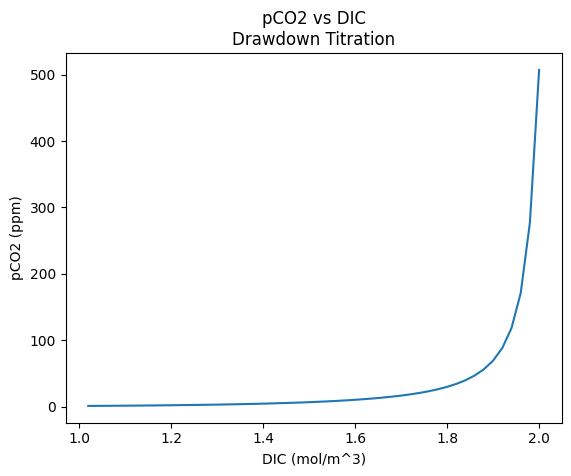

In [3]:
dic_values = []
pCO2_values = []

step = 0.00002 
n_steps = 50 

for i in range(n_steps):
    dic = DIC - (i * step)
    dic_values.append(dic * 1000)  # mol/m^3
    _, _, _, pCO2 = solver_loop(pH_low, pH_high, dic, alk)
    pCO2_values.append(pCO2)

plt.plot(dic_values, pCO2_values)
plt.xlabel('DIC (mol/m^3)')
plt.ylabel('pCO2 (ppm)')
plt.title('pCO2 vs DIC\nDrawdown Titration')
plt.show()